In [2]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [3]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [4]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [5]:
df = df.dropna()

In [6]:
import pandas as pd

# userid별 주문 수 파악
orders_per_customer = df.groupby('idUser').size().reset_index(name='order_count')

print("=== userid별 주문 수 (상위 20개) ===")
print(orders_per_customer.head(20))

print("\n=== order_count의 describe() 통계 ===")
print(orders_per_customer['order_count'].describe())

print(f"\n전체 고객 수: {len(orders_per_customer)}")
print(f"전체 주문 수: {len(df)}")

=== userid별 주문 수 (상위 20개) ===
    idUser  order_count
0   U10001          347
1   U10002          269
2   U10003          289
3   U10004          161
4   U10005          371
5   U10006          351
6   U10007          376
7   U10008          327
8   U10009          124
9   U10010          136
10  U10011          301
11  U10012          219
12  U10013          413
13  U10014          281
14  U10015          244
15  U10016          276
16  U10017          203
17  U10018          287
18  U10019          341
19  U10020          266

=== order_count의 describe() 통계 ===
count    3000.000000
mean      284.700333
std        64.090429
min        52.000000
25%       244.000000
50%       290.000000
75%       330.000000
max       479.000000
Name: order_count, dtype: float64

전체 고객 수: 3000
전체 주문 수: 854101


# 연관분석

In [7]:
# ============================================
# 1. 고객별 연관분석 (Customer-level Association Analysis)
# ============================================

# 고객별로 구매한 상품 리스트 생성
customer_products = df.groupby('idUser')['ItemSmallName'].apply(list).reset_index()
customer_products.columns = ['idUser', 'products']

print(f"총 고객수: {len(customer_products)}")
print(f"평균 구매상품수: {customer_products['products'].apply(len).mean():.2f}")

# 거래 데이터 인코딩 (One-hot encoding)
te = TransactionEncoder()
te_ary = te.fit(customer_products['products']).transform(customer_products['products'])
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"상품 종류: {len(df_encoded.columns)}")
print(f"분석 시작...")

# Apriori 알고리즘으로 빈도 있는 항목집합 찾기 (최소 지지도 5%, 최대 길이 3)
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True, max_len=3)

print(f"✓ 발견된 빈번한 항목집합: {len(frequent_itemsets)}개")

# 연관성 규칙 생성
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
    
    if len(rules) > 0:
        # Lift 값으로 정렬
        rules = rules.sort_values('lift', ascending=False)
        
        # 중복 제거 (같은 상품 쌍 중 Lift가 높은 방향 유지)
        rules_display = rules.copy()
        rules_display['상품A_temp'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules_display['상품B_temp'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
        rules_display['pair_key'] = rules_display.apply(
            lambda r: tuple(sorted([r['상품A_temp'], r['상품B_temp']])), axis=1
        )
        rules_display = rules_display.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
        
        # 이후 셀에서 사용할 수 있도록 rules 업데이트
        rules = rules_display.drop(columns=['상품A_temp', '상품B_temp', 'pair_key'])
        
        print("=" * 100)
        print("【고객별 연관분석 결과】")
        print("=" * 100)
        print(f"\n전체 규칙: {len(rules)}개 (중복 제거 완료)")
        print("\n[상위 15개 규칙 - Lift 순으로 정렬]\n")
        
        display_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
        display_rules['상품A'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        display_rules['상품B'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
        result_df = display_rules[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
        result_df.index = result_df.index + 1
        result_df.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
        print(result_df.to_string())
        print("\n[설명]")
        print("- Support: 두 상품이 함께 구매된 비율")
        print("- Confidence: 상품A 구매 시 상품B를 구매할 확률")
        print("- Lift: 1보다 크면 양의 상관관계 있음 (높을수록 강함)")
    else:
        print("신뢰도가 0.4 이상인 규칙이 없습니다.")
        rules = pd.DataFrame()
else:
    print("지지도가 0.05 이상인 항목집합이 없습니다.")
    rules = pd.DataFrame()

총 고객수: 3000
평균 구매상품수: 284.70
상품 종류: 58
분석 시작...
✓ 발견된 빈번한 항목집합: 32567개


/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


【고객별 연관분석 결과】

전체 규칙: 94210개 (중복 제거 완료)

[상위 15개 규칙 - Lift 순으로 정렬]

         상품 A      상품 B   Support  Confidence      Lift
1         콩나물   갈치, 파스타  0.132667    0.523684  1.175058
2    파스타, 콩나물        갈치  0.132667    0.673435  1.153800
3         콩나물  갈치, 탄산음료  0.119333    0.471053  1.147976
4   콩나물, 탄산음료        갈치  0.119333    0.667910  1.144335
5         콩나물    갈치, 깻잎  0.104000    0.410526  1.142467
6         콩나물   갈치, 아몬드  0.144333    0.569737  1.132678
7         콩나물    갈치, 조기  0.114000    0.450000  1.132550
8         콩나물    갈치, 멸치  0.158333    0.625000  1.130199
9         콩나물    갈치, 맛김  0.151333    0.597368  1.124988
10        콩나물    갈치, 생수  0.124667    0.492105  1.121821
11    깻잎, 콩나물        갈치  0.104000    0.654088  1.120653
12        콩나물    멸치, 참외  0.120333    0.475000  1.116771
13        콩나물    갈치, 국수  0.148333    0.585526  1.116706
14        콩나물    갈치, 북어  0.133333    0.526316  1.116653
15    조기, 콩나물        갈치  0.114000    0.651429  1.116097

[설명]
- Support: 두 상품이 함께 구매된 비율
- C

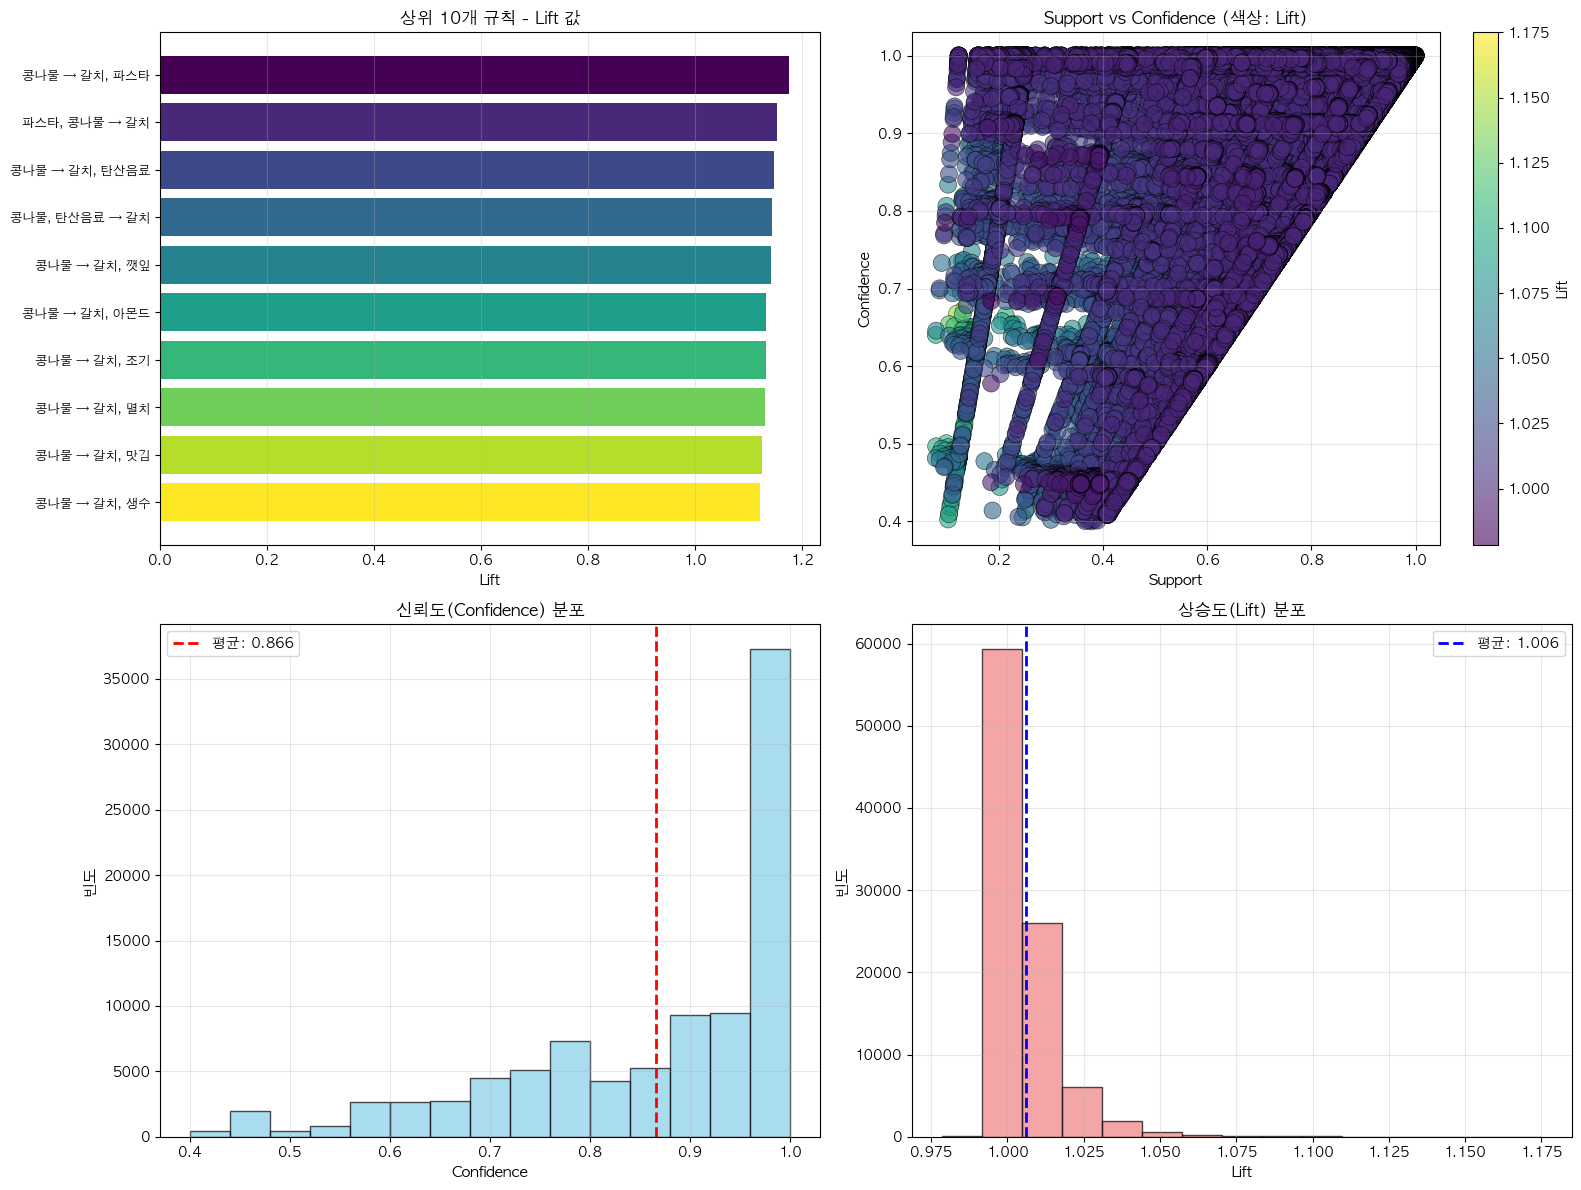


✓ 고객별 연관분석 시각화 저장: customer_association_analysis.png


In [8]:
# 고객별 연관분석 시각화
if len(rules) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Lift 상위 10개 시각화
    top_rules = rules.head(10)
    ax = axes[0, 0]
    rules_labels = []
    for x, y in zip(top_rules['antecedents'], top_rules['consequents']):
        ant = ', '.join(list(x))
        cons = ', '.join(list(y))
        if len(ant) > 15:
            ant = ant[:15] + '...'
        if len(cons) > 15:
            cons = cons[:15] + '...'
        rules_labels.append(f"{ant} → {cons}")
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_rules)))
    ax.barh(range(len(top_rules)), top_rules['lift'].values, color=colors)
    ax.set_yticks(range(len(top_rules)))
    ax.set_yticklabels(rules_labels, fontsize=9)
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_title('상위 10개 규칙 - Lift 값', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # 2. Support vs Confidence 산점도
    ax = axes[0, 1]
    scatter = ax.scatter(rules['support'], rules['confidence'], 
                        c=rules['lift'], cmap='viridis', s=150, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title('Support vs Confidence (색상: Lift)', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Lift', fontsize=10)
    ax.grid(alpha=0.3)
    
    # 3. Confidence 분포
    ax = axes[1, 0]
    ax.hist(rules['confidence'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('신뢰도(Confidence) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {rules["confidence"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Lift 분포
    ax = axes[1, 1]
    ax.hist(rules['lift'], bins=15, edgecolor='black', alpha=0.7, color='lightcoral')
    ax.set_xlabel('Lift', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title('상승도(Lift) 분포', fontsize=12, fontweight='bold')
    ax.axvline(rules['lift'].mean(), color='blue', linestyle='--', linewidth=2, label=f'평균: {rules["lift"].mean():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('customer_association_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ 고객별 연관분석 시각화 저장: customer_association_analysis.png")
else:
    print("\n규칙이 충분하지 않아 시각화를 생성할 수 없습니다.")

In [9]:
# ============================================
# 2. 연령대별 연관분석 (Age Group Association Analysis)
# ============================================

age_groups = sorted(df['AgeGroup'].unique())
age_group_results = {}

print("\n" + "=" * 100)
print("【연령대별 연관분석 결과】")
print("=" * 100)

for age_group in age_groups:
    # 해당 연령대 데이터 필터링
    age_df = df[df['AgeGroup'] == age_group]
    
    # 연령대별 구매 상품 리스트 (상품명 사용)
    age_products = age_df.groupby('idUser')['ItemSmallName'].apply(list).reset_index()
    age_products.columns = ['idUser', 'products']
    
    # 거래 데이터 인코딩
    te_age = TransactionEncoder()
    te_age_ary = te_age.fit(age_products['products']).transform(age_products['products'])
    df_age_encoded = pd.DataFrame(te_age_ary, columns=te_age.columns_)
    
    # Apriori 알고리즘 (최소 지지도 8%, 최대 길이 2)
    frequent_itemsets_age = apriori(df_age_encoded, min_support=0.08, use_colnames=True, max_len=2)
    
    # 연관성 규칙 생성
    if len(frequent_itemsets_age) > 0:
        rules_age = association_rules(frequent_itemsets_age, metric="confidence", min_threshold=0.4)
        
        if len(rules_age) > 0:
            rules_age = rules_age.sort_values('lift', ascending=False)
            
            # 중복 제거 (같은 상품 쌍 중 Lift가 높은 방향 유지)
            rules_age_dedup = rules_age.copy()
            rules_age_dedup['상품A'] = rules_age_dedup['antecedents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['상품B'] = rules_age_dedup['consequents'].apply(lambda x: ', '.join(list(x)))
            rules_age_dedup['pair_key'] = rules_age_dedup.apply(
                lambda r: tuple(sorted([r['상품A'], r['상품B']])), axis=1
            )
            rules_age_dedup = rules_age_dedup.sort_values('lift', ascending=False).drop_duplicates(subset='pair_key', keep='first')
            
            age_group_results[age_group] = rules_age_dedup
            
            print(f"\n【{age_group}대】({len(age_df)} 건 거래, {age_df['idUser'].nunique()} 명 고객)")
            print(f"  전체 규칙: {len(rules_age)}개 → 중복 제거 후: {len(rules_age_dedup)}개 유니크 규칙")
            
            if len(rules_age_dedup) > 0:
                display_rules_age = rules_age_dedup[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).copy()
                display_rules_age['상품A'] = display_rules_age['antecedents'].apply(lambda x: ', '.join(list(x)))
                display_rules_age['상품B'] = display_rules_age['consequents'].apply(lambda x: ', '.join(list(x)))
                result_age = display_rules_age[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
                result_age.index = result_age.index + 1
                result_age.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
                print(result_age.to_string())
        else:
            print(f"\n【{age_group}대】- 조건을 만족하는 규칙이 없습니다.")
    else:
        print(f"\n【{age_group}대】- 지지도가 0.08 이상인 항목집합이 없습니다.")


【연령대별 연관분석 결과】

【20대】(233828 건 거래, 820 명 고객)
  전체 규칙: 3249개 → 중복 제거 후: 1653개 유니크 규칙
  상품 A  상품 B   Support  Confidence      Lift
1   참외    갈치  0.297561    0.659459  1.101338
2  콩나물    참외  0.126829    0.492891  1.092353
3  콩나물  탄산음료  0.178049    0.691943  1.068537
4  콩나물    갈치  0.164634    0.639810  1.068523
5   깻잎  탄산음료  0.409756    0.689938  1.065442


/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)



【30대】(362208 건 거래, 1280 명 고객)
  전체 규칙: 3249개 → 중복 제거 후: 1653개 유니크 규칙
  상품 A 상품 B   Support  Confidence      Lift
1  콩나물   갈치  0.158594    0.659091  1.129366
2  콩나물   조기  0.173437    0.720779  1.102267
3  콩나물   생수  0.188281    0.782468  1.066622
4  파스타   당면  0.546875    0.730689  1.056816
5  콩나물   참외  0.114844    0.477273  1.051479

【40대】(137632 건 거래, 477 명 고객)
  전체 규칙: 3249개 → 중복 제거 후: 1653개 유니크 규칙
  상품 A 상품 B   Support  Confidence      Lift
1  콩나물  파스타  0.205451    0.823529  1.132056
2  콩나물   갈치  0.165618    0.663866  1.130942
3  콩나물   북어  0.218029    0.873950  1.105766
4  콩나물   땅콩  0.218029    0.873950  1.094157
5   참외   조기  0.322851    0.729858  1.081187

【50대】(83760 건 거래, 291 명 고객)
  전체 규칙: 3249개 → 중복 제거 후: 1653개 유니크 규칙
  상품 A 상품 B   Support  Confidence      Lift
1  콩나물   참외  0.144330    0.545455  1.202479
2  콩나물   당면  0.213058    0.805195  1.148587
3   갈치   참외  0.274914    0.503145  1.109205
4  콩나물   갈치  0.158076    0.597403  1.093359
5  조미료   갈치  0.453608    0.597285  1.093144



/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


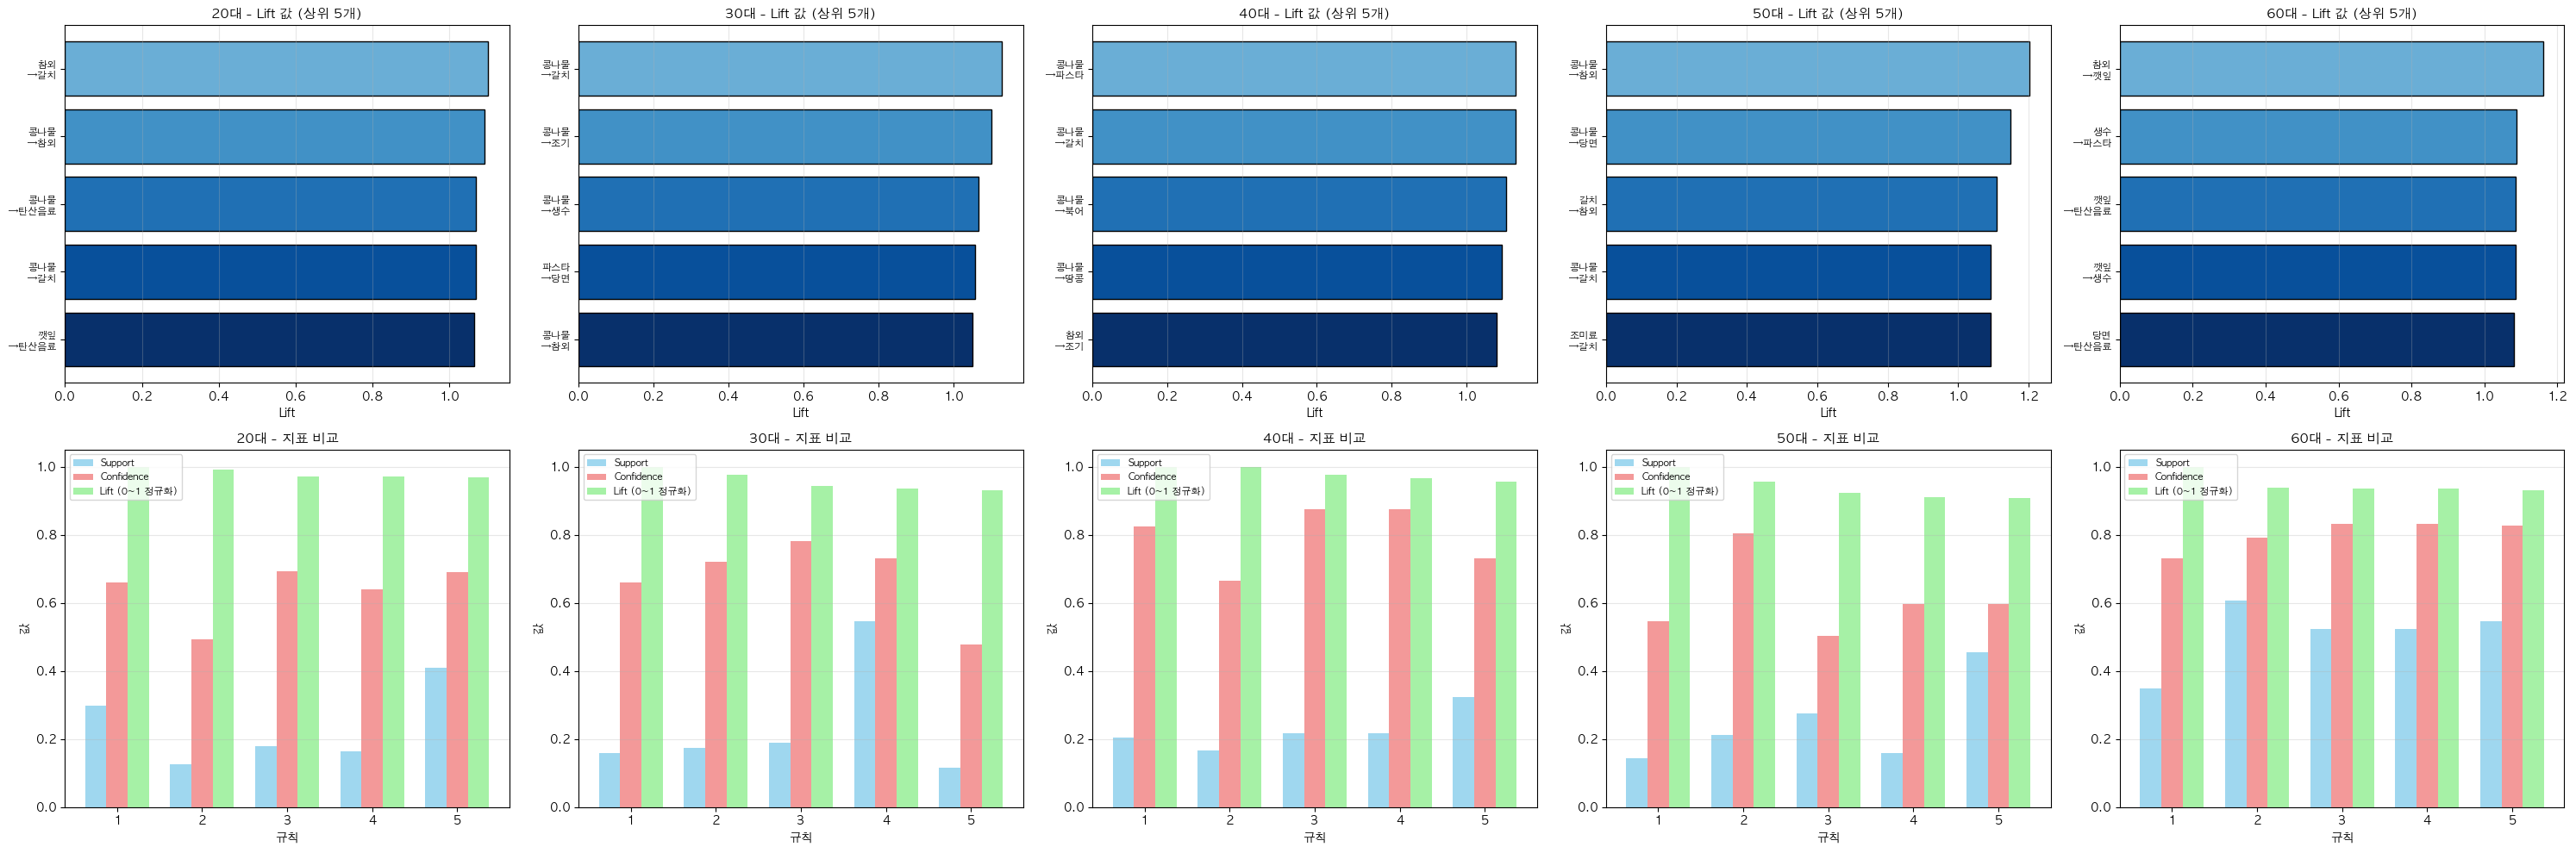


✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis.png


In [10]:
# 연령대별 연관분석 시각화
if age_group_results:
    num_age_groups = len(age_group_results)
    fig, axes = plt.subplots(2, num_age_groups, figsize=(6*num_age_groups, 10))
    
    if num_age_groups == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (age_group, rules_age) in enumerate(age_group_results.items()):
        if len(rules_age) > 0:
            # 상위 5개 규칙
            top_rules_age = rules_age.head(5)
            
            # 1행: Lift 값 비교
            ax = axes[0, idx]
            rules_labels_age = []
            for x, y in zip(top_rules_age['antecedents'], top_rules_age['consequents']):
                ant = ', '.join(list(x))
                cons = ', '.join(list(y))
                if len(ant) > 12:
                    ant = ant[:12] + '...'
                if len(cons) > 12:
                    cons = cons[:12] + '...'
                rules_labels_age.append(f"{ant}\n→{cons}")
            
            colors = plt.cm.Blues(np.linspace(0.5, 1, len(top_rules_age)))
            ax.barh(range(len(top_rules_age)), top_rules_age['lift'].values, color=colors, edgecolor='black')
            ax.set_yticks(range(len(top_rules_age)))
            ax.set_yticklabels(rules_labels_age, fontsize=8)
            ax.set_xlabel('Lift')
            ax.set_title(f'{age_group}대 - Lift 값 (상위 5개)', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(alpha=0.3, axis='x')
            
            # 2행: 지표별 비교 (Support, Confidence, Lift)
            ax = axes[1, idx]
            x_pos = np.arange(len(top_rules_age))
            width = 0.25
            
            ax.bar(x_pos - width, top_rules_age['support'].values, width, label='Support', alpha=0.8, color='skyblue')
            ax.bar(x_pos, top_rules_age['confidence'].values, width, label='Confidence', alpha=0.8, color='lightcoral')
            ax.bar(x_pos + width, top_rules_age['lift'].values/max(rules_age['lift'].values), 
                   width, label='Lift (0~1 정규화)', alpha=0.8, color='lightgreen')
            
            ax.set_xlabel('규칙')
            ax.set_ylabel('값')
            ax.set_title(f'{age_group}대 - 지표 비교', fontsize=11, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(range(1, len(top_rules_age)+1))
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('age_group_association_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 연령대별 연관분석 시각화 저장: age_group_association_analysis.png")
else:
    print("\n연령대별 규칙을 찾을 수 없어 시각화를 생성할 수 없습니다.")


【연령대별 비교 분석】

[연령대별 주요 지표]

연령대  고객수   거래건수  규칙수  평균Support  평균Confidence   평균Lift   최대Lift     평균구매상품
20대  820 233828 1653   0.792686      0.903787 1.002973 1.101338 285.156098
30대 1280 362208 1653   0.791280      0.901264 1.003940 1.129366 282.975000
40대  477 137632 1653   0.799667      0.905194 1.002544 1.132056 288.536688
50대  291  83760 1653   0.798376      0.905712 1.003428 1.202479 287.835052
60대  132  36673 1653   0.795317      0.903021 1.003581 1.161216 277.825758


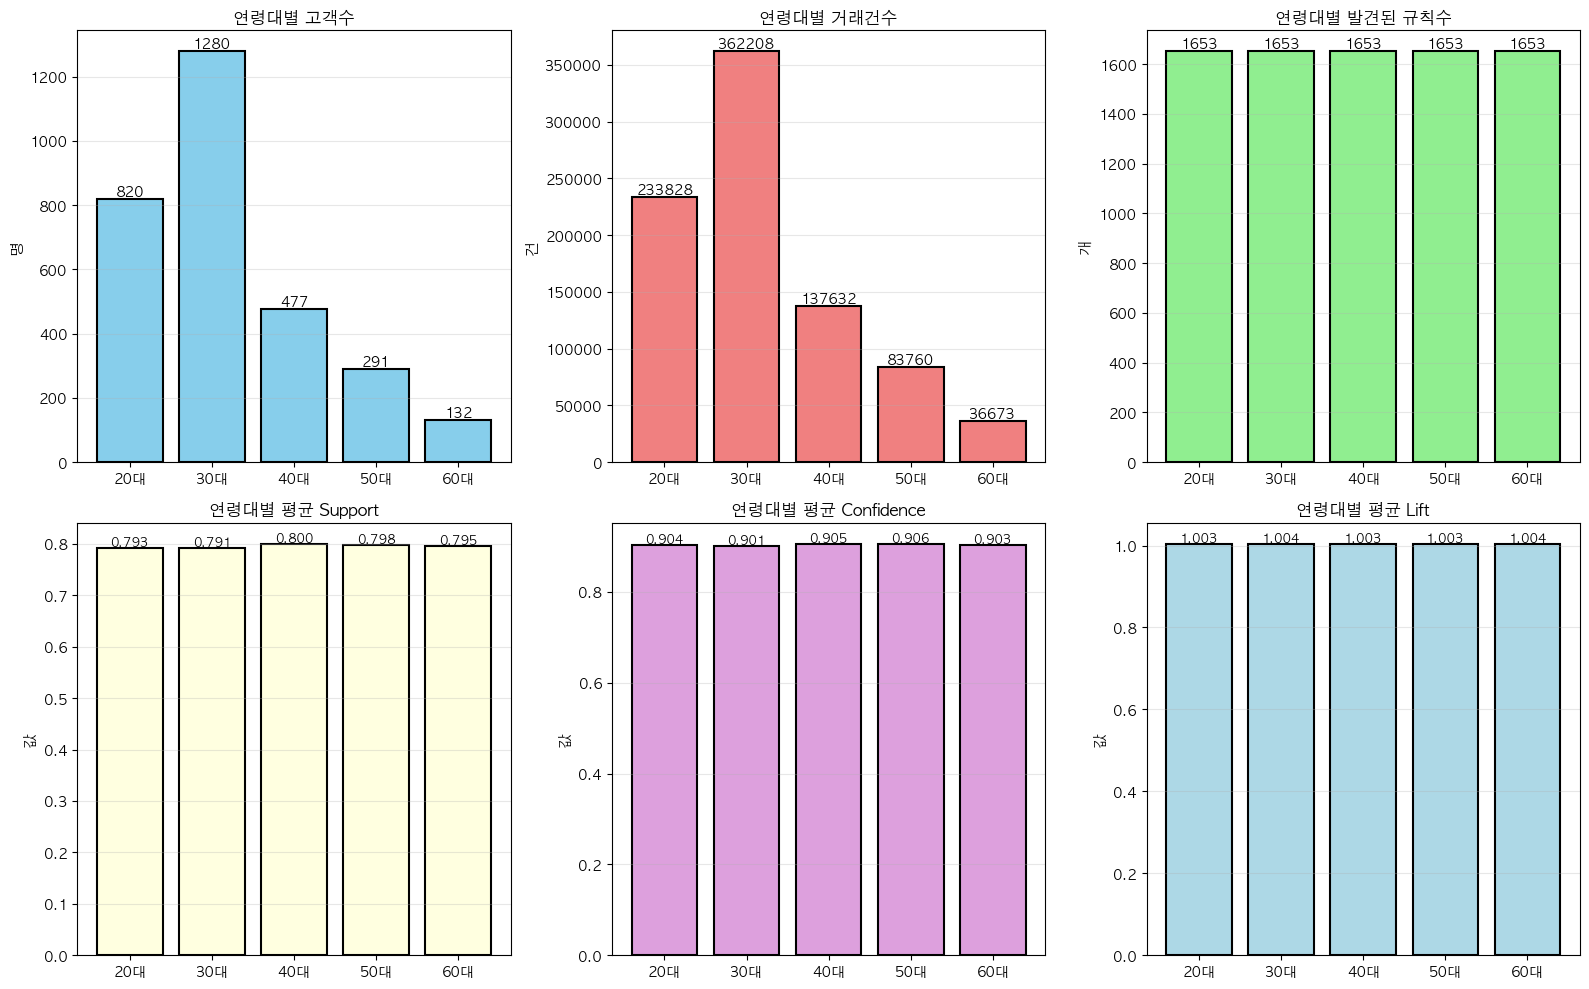


✓ 연령대별 비교 분석 시각화 저장: age_group_comparison.png


In [11]:
# ============================================
# 3. 연령대별 비교 분석 (Comparative Analysis)
# ============================================

print("\n" + "=" * 100)
print("【연령대별 비교 분석】")
print("=" * 100)

# 연령대별 주요 지표 비교
age_comparison = []

for age_group in age_groups:
    age_df = df[df['AgeGroup'] == age_group]
    
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        age_comparison.append({
            '연령대': f'{age_group}대',
            '고객수': age_df['idUser'].nunique(),
            '거래건수': len(age_df),
            '규칙수': len(rules_age),
            '평균Support': rules_age['support'].mean(),
            '평균Confidence': rules_age['confidence'].mean(),
            '평균Lift': rules_age['lift'].mean(),
            '최대Lift': rules_age['lift'].max(),
            '평균구매상품': age_df.groupby('idUser')['ItemSmallName'].count().mean()
        })

comparison_df = pd.DataFrame(age_comparison)
print("\n[연령대별 주요 지표]\n")
print(comparison_df.to_string(index=False))

# 시각화: 연령대별 지표 비교
if len(comparison_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. 고객수
    ax = axes[0, 0]
    ax.bar(comparison_df['연령대'], comparison_df['고객수'], color='skyblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('명', fontsize=11)
    ax.set_title('연령대별 고객수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['고객수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 2. 거래건수
    ax = axes[0, 1]
    ax.bar(comparison_df['연령대'], comparison_df['거래건수'], color='lightcoral', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('건', fontsize=11)
    ax.set_title('연령대별 거래건수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['거래건수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 3. 발견된 규칙수
    ax = axes[0, 2]
    ax.bar(comparison_df['연령대'], comparison_df['규칙수'], color='lightgreen', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('개', fontsize=11)
    ax.set_title('연령대별 발견된 규칙수', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['규칙수']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 4. 평균 Support
    ax = axes[1, 0]
    ax.bar(comparison_df['연령대'], comparison_df['평균Support'], color='lightyellow', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Support', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Support']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # 5. 평균 Confidence
    ax = axes[1, 1]
    ax.bar(comparison_df['연령대'], comparison_df['평균Confidence'], color='plum', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Confidence', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Confidence']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # 6. 평균 Lift
    ax = axes[1, 2]
    ax.bar(comparison_df['연령대'], comparison_df['평균Lift'], color='lightblue', edgecolor='black', linewidth=1.5)
    ax.set_ylabel('값', fontsize=11)
    ax.set_title('연령대별 평균 Lift', fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(comparison_df['평균Lift']):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('age_group_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 연령대별 비교 분석 시각화 저장: age_group_comparison.png")

In [12]:
# ============================================
# 4. 주요 인사이트 및 요약 분석
# ============================================

print("\n" + "=" * 100)
print("【주요 인사이트 및 분석 요약】")
print("=" * 100)

if len(rules) > 0:
    print("\n[전체 고객 연관분석 요약]")
    print(f"  ✓ 발견된 규칙 수(중복 제거): {len(rules)}개")
    print(f"  ✓ 평균 Support: {rules['support'].mean():.4f}")
    print(f"  ✓ 평균 Confidence: {rules['confidence'].mean():.4f}")
    print(f"  ✓ 평균 Lift: {rules['lift'].mean():.4f}")
    print(f"  ✓ 최고 Lift: {rules['lift'].max():.4f}")
    
    # 가장 강력한 규칙 찾기
    strongest_rule = rules.loc[rules['lift'].idxmax()]
    print(f"\n[가장 강력한 연관규칙]")
    ant_name = ', '.join(list(strongest_rule['antecedents']))
    cons_name = ', '.join(list(strongest_rule['consequents']))
    print(f"  ✓ 상품 A: {ant_name}")
    print(f"  ✓ 상품 B: {cons_name}")
    print(f"  ✓ 의미: {ant_name}을(를) 구매한 고객이 {cons_name}을(를) 구매할 확률")
    print(f"         {ant_name}을(를) 구매했을 때, 전체 고객 대비 {cons_name}을(를) 구매할 확률이 {(strongest_rule['lift']-1)*100:.1f}% 증가")
    print(f"  ✓ Confidence: {strongest_rule['confidence']:.1%}")
    print(f"  ✓ Support: {strongest_rule['support']:.4f}")
    
    # 가장 많이 등장하는 상품 찾기
    from collections import Counter
    antecedents_list = []
    consequents_list = []
    
    for ant in rules['antecedents']:
        antecedents_list.extend(list(ant))
    for cons in rules['consequents']:
        consequents_list.extend(list(cons))
    
    ant_counter = Counter(antecedents_list)
    cons_counter = Counter(consequents_list)
    
    print(f"\n[가장 자주 선행상품으로 나타나는 상품 TOP 5]")
    for rank, (product, count) in enumerate(ant_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")
    
    print(f"\n[가장 자주 결과상품으로 나타나는 상품 TOP 5]")
    for rank, (product, count) in enumerate(cons_counter.most_common(5), 1):
        print(f"  {rank}. {product}: {count}회")

# 연령대별 특징
if len(comparison_df) > 0:
    print(f"\n[연령대별 특징]")
    max_customer_idx = comparison_df['고객수'].idxmax()
    max_rules_idx = comparison_df['규칙수'].idxmax()
    max_lift_idx = comparison_df['평균Lift'].idxmax()
    max_conf_idx = comparison_df['평균Confidence'].idxmax()
    
    print(f"  ✓ 가장 많은 고객을 보유: {comparison_df.loc[max_customer_idx, '연령대']} ({int(comparison_df.loc[max_customer_idx, '고객수'])}명)")
    print(f"  ✓ 가장 많은 규칙 발견: {comparison_df.loc[max_rules_idx, '연령대']} ({int(comparison_df.loc[max_rules_idx, '규칙수'])}개)")
    print(f"  ✓ 평균 Lift 최고: {comparison_df.loc[max_lift_idx, '연령대']} ({comparison_df.loc[max_lift_idx, '평균Lift']:.4f})")
    print(f"  ✓ 평균 Confidence 최고: {comparison_df.loc[max_conf_idx, '연령대']} ({comparison_df.loc[max_conf_idx, '평균Confidence']:.4f})")

print("\n" + "=" * 100)
print("✅ 분석 완료!")
print("=" * 100)


【주요 인사이트 및 분석 요약】

[전체 고객 연관분석 요약]
  ✓ 발견된 규칙 수(중복 제거): 94210개
  ✓ 평균 Support: 0.7107
  ✓ 평균 Confidence: 0.8661
  ✓ 평균 Lift: 1.0062
  ✓ 최고 Lift: 1.1751

[가장 강력한 연관규칙]
  ✓ 상품 A: 콩나물
  ✓ 상품 B: 갈치, 파스타
  ✓ 의미: 콩나물을(를) 구매한 고객이 갈치, 파스타을(를) 구매할 확률
         콩나물을(를) 구매했을 때, 전체 고객 대비 갈치, 파스타을(를) 구매할 확률이 17.5% 증가
  ✓ Confidence: 52.4%
  ✓ Support: 0.1327

[가장 자주 선행상품으로 나타나는 상품 TOP 5]
  1. 콩나물: 4834회
  2. 참외: 2818회
  3. 돼지고기: 2471회
  4. 탄산음료: 2467회
  5. 멸치: 2455회

[가장 자주 결과상품으로 나타나는 상품 TOP 5]
  1. 카레: 2530회
  2. 과일: 2515회
  3. 갈치: 2512회
  4. 나물: 2512회
  5. 빵: 2512회

[연령대별 특징]
  ✓ 가장 많은 고객을 보유: 30대 (1280명)
  ✓ 가장 많은 규칙 발견: 20대 (1653개)
  ✓ 평균 Lift 최고: 30대 (1.0039)
  ✓ 평균 Confidence 최고: 50대 (0.9057)

✅ 분석 완료!


In [13]:
# ============================================
# 5. 연령대별 연관상품 TOP 10 (중복 제거 완료)
# ============================================

print("\n" + "=" * 120)
print("【연령대별 연관상품 TOP 10】(같은 상품 쌍 중복 제거))")
print("=" * 120)

for age_group in age_groups:
    if age_group in age_group_results:
        rules_age = age_group_results[age_group]
        
        if len(rules_age) > 0:
            # TOP 10 추출 (이미 중복 제거된 상태)
            top_10 = rules_age.head(10).copy()
            top_10['상품A'] = top_10['antecedents'].apply(lambda x: ', '.join(list(x)))
            top_10['상품B'] = top_10['consequents'].apply(lambda x: ', '.join(list(x)))
            
            print(f"\n【{age_group}대】유니크 규칙 {len(rules_age)}개 중 상위 10개")
            print("-" * 120)
            
            result_table = top_10[['상품A', '상품B', 'support', 'confidence', 'lift']].reset_index(drop=True)
            result_table.index = result_table.index + 1
            result_table.columns = ['상품 A', '상품 B', 'Support', 'Confidence', 'Lift']
            
            # 각 지표를 읽기 쉽게 포맷
            for col in ['Support', 'Confidence', 'Lift']:
                if col == 'Support':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
                elif col == 'Confidence':
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.1%}')
                else:  # Lift
                    result_table[col] = result_table[col].apply(lambda x: f'{x:.4f}')
            
            print(result_table.to_string())
            print()
        else:
            print(f"\n【{age_group}대】규칙이 없습니다.\n")

print("=" * 120)


【연령대별 연관상품 TOP 10】(같은 상품 쌍 중복 제거))

【20대】유니크 규칙 1653개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
   상품 A  상품 B Support Confidence    Lift
1    참외    갈치  0.2976      65.9%  1.1013
2   콩나물    참외  0.1268      49.3%  1.0924
3   콩나물  탄산음료  0.1780      69.2%  1.0685
4   콩나물    갈치  0.1646      64.0%  1.0685
5    깻잎  탄산음료  0.4098      69.0%  1.0654
6   콩나물   아몬드  0.2268      88.2%  1.0568
7   콩나물    땅콩  0.2049      79.6%  1.0565
8    깻잎   파스타  0.4646      78.2%  1.0517
9    갈치    깻잎  0.3732      62.3%  1.0494
10   참외    북어  0.3671      81.4%  1.0472


【30대】유니크 규칙 1653개 중 상위 10개
------------------------------------------------------------------------------------------------------------------------
   상품 A  상품 B Support Confidence    Lift
1   콩나물    갈치  0.1586      65.9%  1.1294
2   콩나물    조기  0.1734      72.1%  1.1023
3   콩나물    생수  0.1883      78.2%  1.0666
4   파스타    당면  0.5469      73.1%  1.0568
5   콩나물  

In [14]:
# ============================================
# 6. 연관규칙 JSON 내보내기 (웹 시각화용)
# ============================================
import json, os

os.makedirs('web/public/data', exist_ok=True)

# 전체 고객단위 연관규칙 (lift 상위 500개)
export_rules = []
if len(rules) > 0:
    top_rules = rules.nlargest(500, 'lift')
    for _, row in top_rules.iterrows():
        export_rules.append({
            'antecedents': list(row['antecedents']),
            'consequents': list(row['consequents']),
            'support': round(row['support'], 4),
            'confidence': round(row['confidence'], 4),
            'lift': round(row['lift'], 4),
            'ageGroup': '전체'
        })

# 연령대별 연관규칙
age_rules_export = []
for age_group, rules_age in age_group_results.items():
    top_age = rules_age.nlargest(100, 'lift')
    for _, row in top_age.iterrows():
        age_rules_export.append({
            'antecedents': list(row['antecedents']),
            'consequents': list(row['consequents']),
            'support': round(row['support'], 4),
            'confidence': round(row['confidence'], 4),
            'lift': round(row['lift'], 4),
            'ageGroup': f'{age_group}대'
        })

all_rules = export_rules + age_rules_export

with open('web/public/data/association_rules.json', 'w', encoding='utf-8') as f:
    json.dump(all_rules, f, ensure_ascii=False, indent=2)

print(f"✓ 전체 규칙 {len(export_rules)}개 + 연령대별 {len(age_rules_export)}개 = 총 {len(all_rules)}개 내보내기 완료")
print(f"  → web/public/data/association_rules.json")

✓ 전체 규칙 500개 + 연령대별 500개 = 총 1000개 내보내기 완료
  → web/public/data/association_rules.json
